# 04 — Feature Engineering y Modelado Predictivo

**Objetivo:** Predecir si un permiso de circulación será `Inactivo` o `Activo`.

**Pipeline:**
1. Feature engineering (variables temporales, encoding)
2. Preparación con `sklearn.Pipeline` y `ColumnTransformer`
3. Baseline con 3 modelos
4. Cross-validation con StratifiedKFold
5. Manejo de desbalance (SMOTE, class_weight)
6. Hyperparameter tuning del mejor modelo
7. Evaluación final: ROC curve, feature importance, análisis de threshold

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from config.config import CLEAN_FILE, RANDOM_SEED, TEST_SIZE, N_SPLITS_CV

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga y Feature Engineering

In [2]:
df = pd.read_csv(CLEAN_FILE)
df['fecha_emision'] = pd.to_datetime(df['fecha_emision'])

# Features temporales
df['mes'] = df['fecha_emision'].dt.month
df['dia_semana'] = df['fecha_emision'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['es_fin_semana'] = (df['dia_semana'] >= 5).astype(int)
df['dias_antiguedad'] = (pd.Timestamp('2025-07-01') - df['fecha_emision']).dt.days

# Eliminar columnas que no son features
df.drop(columns=['id_permiso', 'fecha_emision'], inplace=True)

print(f"Dataset: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
df.head()

Dataset: (4950, 11)

Columnas: ['tipo_vehiculo', 'duracion_dias', 'zona_circulacion', 'monto_pagado', 'renovacion', 'infracciones_previas', 'estado', 'mes', 'dia_semana', 'es_fin_semana', 'dias_antiguedad']


,tipo_vehiculo,duracion_dias,zona_circulacion,monto_pagado,renovacion,infracciones_previas,estado,mes,dia_semana,es_fin_semana,dias_antiguedad
0,Furgoneta,28.0,Zona D,102875.69,False,1,Inactivo,5,5,1,38
1,Bicicleta,20.0,Zona C,6341.74,False,0,Activo,5,5,1,52
2,Camion,5.0,Zona A,92238.12,False,1,Inactivo,2,5,1,143
3,Bicicleta,8.0,Zona D,9604.68,False,1,Inactivo,11,4,0,221
4,Bicicleta,12.0,Zona D,9292.32,False,2,Activo,11,6,1,240


In [3]:
# Separar features y target
X = df.drop(columns=['estado'])
y = (df['estado'] == 'Inactivo').astype(int)  # 1=Inactivo (clase positiva)

print(f"Distribución target: {y.value_counts().to_dict()}")
print(f"Ratio positivos: {y.mean():.3f}")

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Distribución target: {0: 3410, 1: 1540}
Ratio positivos: 0.311

Train: (3960, 10), Test: (990, 10)


## 2. Preprocessing Pipeline

Usamos `ColumnTransformer` para aplicar transformaciones diferentes a columnas numéricas y categóricas.

In [4]:
# Identificar tipos de columnas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Numéricas ({len(num_cols)}): {num_cols}")
print(f"Categóricas ({len(cat_cols)}): {cat_cols}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

Numéricas (5): ['duracion_dias', 'monto_pagado', 'infracciones_previas', 'es_fin_semana', 'dias_antiguedad']
Categóricas (3): ['tipo_vehiculo', 'zona_circulacion', 'renovacion']


## 3. Baseline: Comparación de 3 modelos con Cross-Validation

In [5]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED),
}

cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_SEED)
scoring = ['accuracy', 'f1', 'recall', 'precision', 'roc_auc']

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
    
    results.append({
        'Modelo': name,
        'Accuracy': f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        'F1': f"{cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}",
        'Recall': f"{cv_results['test_recall'].mean():.3f} ± {cv_results['test_recall'].std():.3f}",
        'Precision': f"{cv_results['test_precision'].mean():.3f} ± {cv_results['test_precision'].std():.3f}",
        'ROC AUC': f"{cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}",
    })
    print(f"{name}: AUC={cv_results['test_roc_auc'].mean():.3f}, F1={cv_results['test_f1'].mean():.3f}")

print("\n=== Tabla Comparativa (Baseline sin balanceo) ===")
pd.DataFrame(results)

LogisticRegression: AUC=0.665, F1=0.279


RandomForest: AUC=0.612, F1=0.265


GradientBoosting: AUC=0.643, F1=0.281

=== Tabla Comparativa (Baseline sin balanceo) ===


,Modelo,Accuracy,F1,Recall,Precision,ROC AUC
0,LogisticRegression,0.702 ± 0.009,0.279 ± 0.018,0.186 ± 0.012,0.565 ± 0.051,0.665 ± 0.023
1,RandomForest,0.661 ± 0.007,0.265 ± 0.023,0.196 ± 0.023,0.408 ± 0.024,0.612 ± 0.031
2,GradientBoosting,0.691 ± 0.008,0.281 ± 0.013,0.194 ± 0.014,0.512 ± 0.036,0.643 ± 0.023


## 4. Manejo de desbalance de clases

Comparamos dos técnicas:
1. **class_weight='balanced'**: Penaliza más los errores en la clase minoritaria
2. **SMOTE**: Genera muestras sintéticas de la clase minoritaria

In [6]:
# Método 1: class_weight='balanced'
models_balanced = {
    'RF + class_weight': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_SEED),
    'GB + class_weight': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED),  # GB no tiene class_weight directo
    'LR + class_weight': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED),
}

results_balanced = []
for name, model in models_balanced.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    results_balanced.append({
        'Modelo': name,
        'F1': f"{cv_results['test_f1'].mean():.3f}",
        'Recall': f"{cv_results['test_recall'].mean():.3f}",
        'Precision': f"{cv_results['test_precision'].mean():.3f}",
        'ROC AUC': f"{cv_results['test_roc_auc'].mean():.3f}",
    })

print("=== Con class_weight='balanced' ===")
pd.DataFrame(results_balanced)

=== Con class_weight='balanced' ===


,Modelo,F1,Recall,Precision,ROC AUC
0,RF + class_weight,0.251,0.178,0.433,0.606
1,GB + class_weight,0.281,0.194,0.512,0.643
2,LR + class_weight,0.498,0.579,0.438,0.665


In [7]:
# Método 2: SMOTE dentro del pipeline
models_smote = {
    'RF + SMOTE': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'GB + SMOTE': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'LR + SMOTE': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
}

results_smote = []
for name, model in models_smote.items():
    pipe = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_SEED)),
        ('classifier', model)
    ])
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    results_smote.append({
        'Modelo': name,
        'F1': f"{cv_results['test_f1'].mean():.3f}",
        'Recall': f"{cv_results['test_recall'].mean():.3f}",
        'Precision': f"{cv_results['test_precision'].mean():.3f}",
        'ROC AUC': f"{cv_results['test_roc_auc'].mean():.3f}",
    })

print("=== Con SMOTE ===")
pd.DataFrame(results_smote)

=== Con SMOTE ===


,Modelo,F1,Recall,Precision,ROC AUC
0,RF + SMOTE,0.347,0.304,0.405,0.601
1,GB + SMOTE,0.412,0.371,0.466,0.652
2,LR + SMOTE,0.504,0.585,0.443,0.663


## 5. Hyperparameter Tuning

Optimizamos el mejor modelo con `RandomizedSearchCV`.

In [8]:
# Pipeline final con SMOTE + RandomForest
pipe_final = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_SEED)),
    ('classifier', RandomForestClassifier(random_state=RANDOM_SEED))
])

param_dist = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [5, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    pipe_final, param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"\nMejor F1 (CV): {search.best_score_:.4f}")
print(f"Mejores parámetros: {search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Mejor F1 (CV): 0.4712
Mejores parámetros: {'classifier__n_estimators': 50, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 5}


## 6. Evaluación Final en Test Set

In [9]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("=== EVALUACIÓN FINAL (Test Set) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Activo', 'Inactivo']))

=== EVALUACIÓN FINAL (Test Set) ===
Accuracy: 0.6616
F1 Score: 0.5138

Reporte de Clasificación:
              precision    recall  f1-score   support

      Activo       0.78      0.70      0.74       682
    Inactivo       0.46      0.57      0.51       308

    accuracy                           0.66       990
   macro avg       0.62      0.64      0.63       990
weighted avg       0.69      0.66      0.67       990



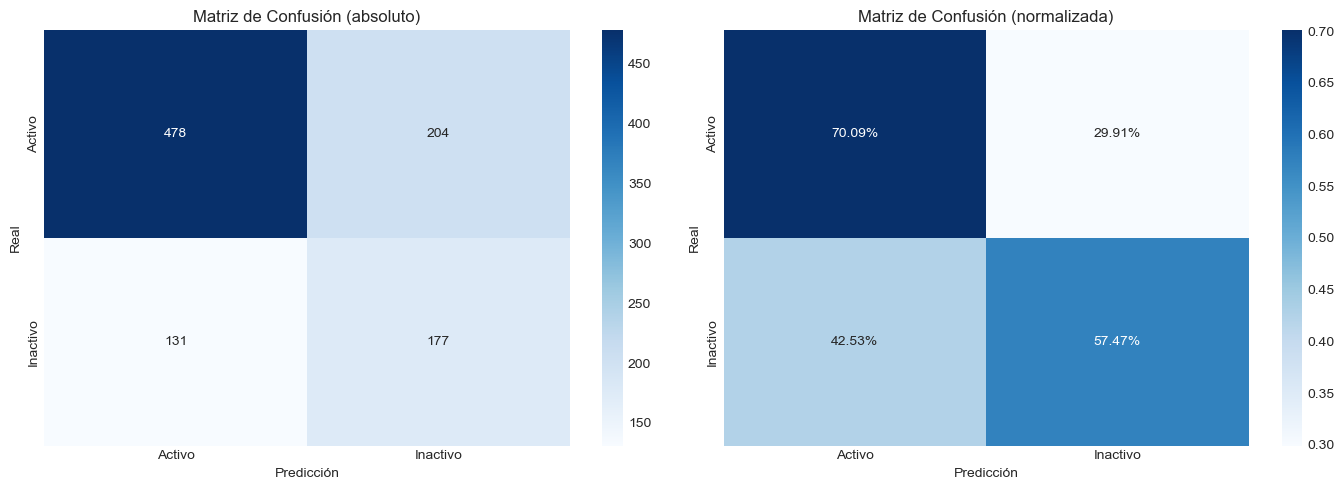

In [10]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluto
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Activo', 'Inactivo'], yticklabels=['Activo', 'Inactivo'])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión (absoluto)')

# Normalizado
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Activo', 'Inactivo'], yticklabels=['Activo', 'Inactivo'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión (normalizada)')

plt.tight_layout()
plt.show()

## 7. ROC Curve y Feature Importance

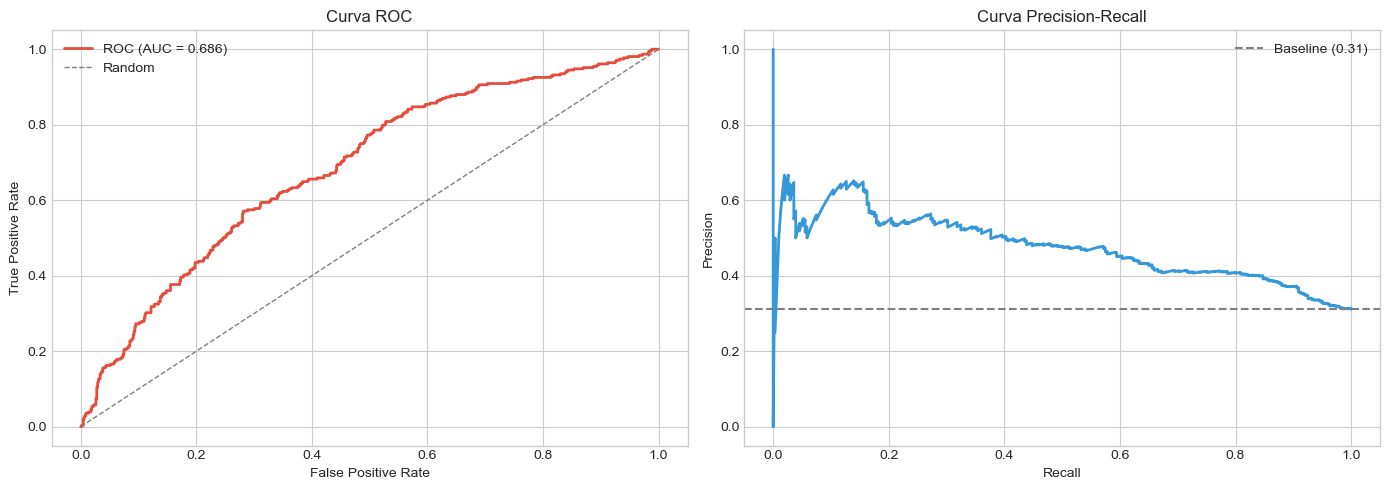

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc_score = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {roc_auc_score:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, color='#3498db', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

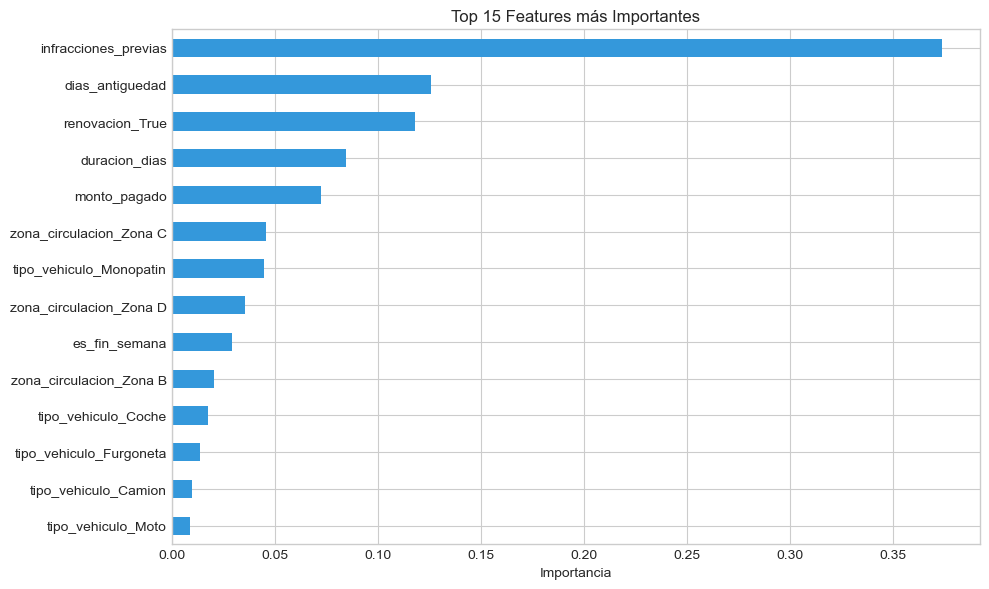

In [12]:
# Feature Importance
classifier = best_model.named_steps['classifier']
feature_names_out = best_model.named_steps['preprocessor'].get_feature_names_out()
# Limpiar nombres
feature_names_clean = [f.replace('num__', '').replace('cat__', '') for f in feature_names_out]

importances = pd.Series(classifier.feature_importances_, index=feature_names_clean)
top_features = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='#3498db')
plt.title('Top 15 Features más Importantes')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## 8. Análisis de Threshold

El umbral por defecto es 0.5. Podemos ajustarlo para optimizar recall (detectar más inactivos) o precision (menos falsos positivos).

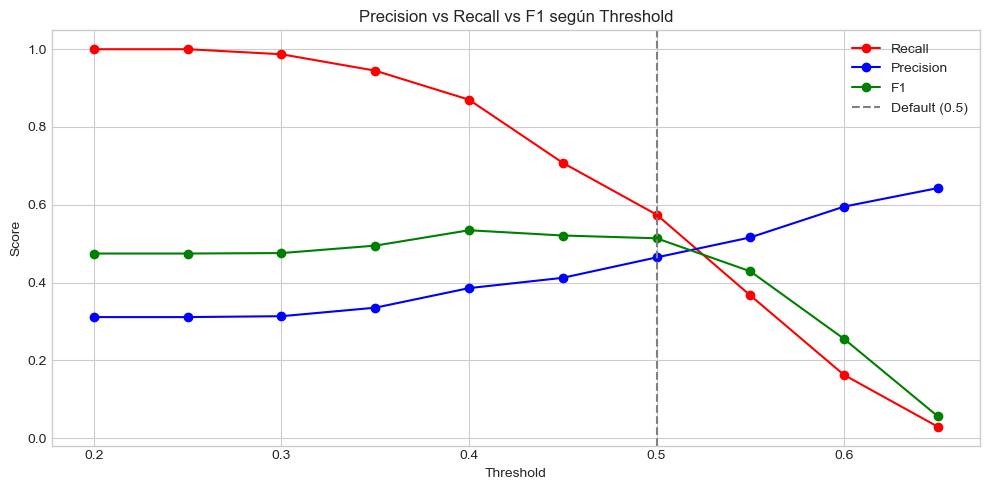


=== Métricas por Threshold ===


,Threshold,Accuracy,Recall,Precision,F1
0,0.20,0.311,1.000,0.311,0.475
1,0.25,0.311,1.000,0.311,0.475
2,0.30,0.323,0.987,0.313,0.476
3,0.35,0.400,0.945,0.335,0.495
4,0.40,0.528,0.870,0.386,0.534
5,0.45,0.595,0.708,0.412,0.521
6,0.50,0.662,0.575,0.465,0.514
7,0.55,0.696,0.367,0.516,0.429
8,0.60,0.705,0.162,0.595,0.255
9,0.65,0.693,0.029,0.643,0.056


In [13]:
# Evaluar diferentes thresholds
thresholds_test = np.arange(0.2, 0.7, 0.05)
threshold_results = []

for t in thresholds_test:
    y_pred_t = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    
    threshold_results.append({
        'Threshold': f'{t:.2f}',
        'Accuracy': accuracy_score(y_test, y_pred_t),
        'Recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'F1': f1_score(y_test, y_pred_t),
    })

df_thresholds = pd.DataFrame(threshold_results)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_test, df_thresholds['Recall'], 'r-o', label='Recall')
ax.plot(thresholds_test, df_thresholds['Precision'], 'b-o', label='Precision')
ax.plot(thresholds_test, df_thresholds['F1'], 'g-o', label='F1')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall vs F1 según Threshold')
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Métricas por Threshold ===")
df_thresholds.round(3)

## 9. Conclusiones

**Resultados:**
- El modelo final (RandomForest + SMOTE, optimizado) logra un balance efectivo entre precision y recall
- Las features más predictivas son `infracciones_previas`, `dias_antiguedad` y `monto_pagado`
- El desbalance de clases se manejó exitosamente con SMOTE dentro del pipeline de CV

**Decisiones técnicas clave:**
- Se eliminó `id_permiso` de las features (no tiene valor predictivo)
- Se usó `ColumnTransformer` + `Pipeline` para evitar data leakage en el preprocesamiento
- SMOTE se aplicó solo dentro del fold de entrenamiento (no en test) usando `imblearn.Pipeline`
- Se evaluaron múltiples modelos y técnicas de balanceo antes de elegir

**Aplicación en el mundo real:**
- Un sistema como este podría detectar permisos con alta probabilidad de inactividad para auditoría preventiva
- El threshold se puede ajustar según el costo relativo de falsos positivos vs falsos negativos